In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from sklearn.model_selection import train_test_split
import gc
import pickle

# Load dataset efficiently (streaming instead of full RAM load)
dataset_path = "dataset_final.txt"

def load_text(file_path, chunk_size=1024):
    """Load text in chunks to reduce RAM usage"""
    text = []
    with open(file_path, "r", encoding="utf-8") as f:
        while chunk := f.read(chunk_size):
            text.append(chunk.lower())  # Convert to lowercase
    return "".join(text)

story_text = load_text(dataset_path)

# Preprocess: Remove punctuation and split into words
story_text = "".join([char if char.isalnum() or char.isspace() else " " for char in story_text])
words = story_text.split()

# Tokenization
tokenizer = Tokenizer()
tokenizer.fit_on_texts(words)
word_index = tokenizer.word_index
vocab_size = len(word_index) + 1

# Convert words to sequences (Streaming Processing)
window_size = 50
sequences = []
for i in range(len(words) - window_size):
    sequence = tokenizer.texts_to_sequences([" ".join(words[i : i + window_size])])[0]
    sequences.append(sequence)

# Free memory
del story_text, words
gc.collect()

# Padding sequences (safe handling if sequences is empty)
max_length = 50  # Default max length
if sequences:
    max_length = min(50, max(len(seq) for seq in sequences))

sequences = pad_sequences(sequences, maxlen=max_length, padding='pre')

# Splitting Input (X) and Output (y)
X, y = sequences[:, :-1], sequences[:, -1]
y = np.array(y)  # Convert y to NumPy array (avoiding one-hot encoding)

# Reduce dataset size for Colab if needed
subset_size = min(50000, len(X))  # Limit dataset to 50K samples if too large
X, y = X[:subset_size], y[:subset_size]

# Train-test split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

def data_generator(X, y, batch_size=64):  # 🔹 Increased batch size from 16 to 64
    """Generator to yield mini-batches for memory efficiency"""
    while True:
        for i in range(0, len(X), batch_size):
            yield X[i:i + batch_size], y[i:i + batch_size]

train_generator = data_generator(X_train, y_train)
val_generator = data_generator(X_val, y_val)

# Free memory
del X, y, sequences
gc.collect()

# Define LSTM model (Optimized for Memory Usage)
model = Sequential([
    Embedding(vocab_size, 64, input_length=max_length-1),
    LSTM(64, return_sequences=True),
    LSTM(32),
    Dense(128, activation='relu'),
    Dense(vocab_size, activation='softmax')
])

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history = model.fit(train_generator,
                    epochs=10,
                    validation_data=val_generator,
                    steps_per_epoch=len(X_train) // 64,  # Adjusted for new batch size
                    validation_steps=len(X_val) // 64)

# Save the trained model
model.save("egyptian_text_model.keras")

# Save tokenizer
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

print("Training complete. Model and tokenizer saved.")


Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 61s 90ms/step - accuracy: 0.0719 - loss: 6.7136 - val_accuracy: 0.0752 - val_loss: 6.0143
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 130ms/step - accuracy: 0.0780 - loss: 5.7948 - val_accuracy: 0.0984 - val_loss: 5.8418
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 131ms/step - accuracy: 0.1024 - loss: 5.4647 - val_accuracy: 0.1162 - val_loss: 5.6557
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 133ms/step - accuracy: 0.1194 - loss: 5.1645 - val_accuracy: 0.1292 - val_loss: 5.5851
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 130ms/step - accuracy: 0.1392 - loss: 4.9545 - val_accuracy: 0.1409 - val_loss: 5.5489
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 131ms/step - accuracy: 0.1511 - loss: 4.7974 - val_accuracy: 0.1491 - val_loss: 5.5521
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 133ms/step - accuracy: 0.1638 - loss: 4.6655 - val_accuracy: 0.1572 - val_loss: 5.5667
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 130ms/step - accuracy: 0.1791 - loss: 4.

In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import ReduceLROnPlateau
from sklearn.model_selection import train_test_split
import gc
import pickle

# Load dataset efficiently (streaming instead of full RAM load)
dataset_path = "dataset_final.txt"

def load_text(file_path, chunk_size=1024):
    """Load text in chunks to reduce RAM usage"""
    text = []
    with open(file_path, "r", encoding="utf-8") as f:
        while chunk := f.read(chunk_size):
            text.append(chunk.lower())  # Convert to lowercase
    return "".join(text)

story_text = load_text(dataset_path)

# Preprocess: Remove punctuation and split into words
story_text = "".join([char if char.isalnum() or char.isspace() else " " for char in story_text])
words = story_text.split()

# Tokenization
tokenizer = Tokenizer()
tokenizer.fit_on_texts(words)
word_index = tokenizer.word_index
vocab_size = len(word_index) + 1

# Convert words to sequences (Streaming Processing)
window_size = 50
sequences = []
for i in range(len(words) - window_size):
    sequence = tokenizer.texts_to_sequences([" ".join(words[i : i + window_size])])[0]
    sequences.append(sequence)

# Free memory
del story_text, words
gc.collect()

# Padding sequences (safe handling if sequences is empty)
max_length = 50  # Default max length
if sequences:
    max_length = min(50, max(len(seq) for seq in sequences))

sequences = pad_sequences(sequences, maxlen=max_length, padding='pre')

# Splitting Input (X) and Output (y)
X, y = sequences[:, :-1], sequences[:, -1]
y = np.array(y)  # Convert y to NumPy array (avoiding one-hot encoding)

# Reduce dataset size for Colab if needed
subset_size = min(50000, len(X))  # Limit dataset to 50K samples if too large
X, y = X[:subset_size], y[:subset_size]

# Train-test split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

def data_generator(X, y, batch_size=64):  # 🔹 Increased batch size from 16 to 64
    """Generator to yield mini-batches for memory efficiency"""
    while True:
        for i in range(0, len(X), batch_size):
            yield X[i:i + batch_size], y[i:i + batch_size]

train_generator = data_generator(X_train, y_train)
val_generator = data_generator(X_val, y_val)

# Free memory
del X, y, sequences
gc.collect()

# Define LSTM model (Optimized for Memory Usage + Regularization)
model = Sequential([
    Embedding(vocab_size, 64, input_length=max_length-1),
    LSTM(64, return_sequences=True, kernel_regularizer=l2(0.001)),
    Dropout(0.3),  # Regularization
    LSTM(32, kernel_regularizer=l2(0.001)),
    Dropout(0.3),  # Regularization
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    Dense(vocab_size, activation='softmax')
])

# Compile model with Adam optimizer
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Learning Rate Scheduler
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5, verbose=1)

# Train model
history = model.fit(train_generator,
                    epochs=10,
                    validation_data=val_generator,
                    steps_per_epoch=len(X_train) // 64,
                    validation_steps=len(X_val) // 64,
                    callbacks=[lr_scheduler])  # 🔹 Added learning rate scheduler

# Save the trained model
model.save("egyptian_text_model.keras")

# Save tokenizer
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

print("Training complete. Model and tokenizer saved.")


Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 87ms/step - accuracy: 0.0770 - loss: 6.4157 - val_accuracy: 0.0752 - val_loss: 6.1536 - learning_rate: 0.0010
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 131ms/step - accuracy: 0.0775 - loss: 5.9811 - val_accuracy: 0.0750 - val_loss: 6.1611 - learning_rate: 0.0010
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 87ms/step - accuracy: 0.0782 - loss: 5.8438 - val_accuracy: 0.0779 - val_loss: 6.0619 - learning_rate: 0.0010
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 133ms/step - accuracy: 0.0839 - loss: 5.7024 - val_accuracy: 0.0909 - val_loss: 6.0386 - learning_rate: 0.0010
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 129ms/step - accuracy: 0.0938 - loss: 5.6141 - val_accuracy: 0.0944 - val_loss: 6.0323 - learning_rate: 0.0010
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 132ms/step - accuracy: 0.0978 - loss: 5.5623 - val_accuracy: 0.1004 - val_loss: 6.0083 - learning_rate: 0.0010
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 86ms/step - accuracy: 0.1005 - loss: 5.

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
import pickle

# Load saved model and tokenizer
model = tf.keras.models.load_model("egyptian_text_model.keras")
with open("tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)

# Function to predict next word
def predict_next_word(text, n_words=5):
    for _ in range(n_words):
        sequence = tokenizer.texts_to_sequences([text])[0]
        sequence = pad_sequences([sequence], maxlen=model.input_shape[1], padding='pre')

        # Predict
        predicted_idx = np.argmax(model.predict(sequence), axis=-1)[0]
        predicted_word = next((word for word, index in tokenizer.word_index.items() if index == predicted_idx), None)

        if predicted_word is None:
            break  # Stop if no valid prediction

        text += " " + predicted_word

    return text

# Example usage
seed_text = "the great pharaoh"
generated_text = predict_next_word(seed_text, n_words=10)
print("Generated Text:", generated_text)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
Generated Text: the great pharaoh recitation recitation is the one of the one of the


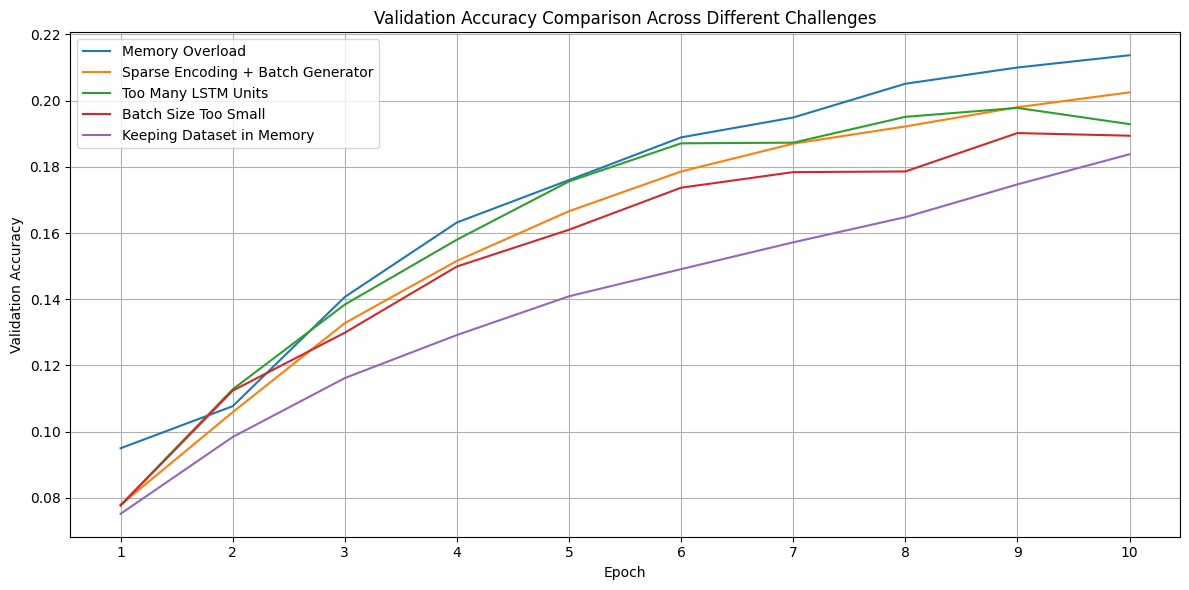

In [ ]:
import matplotlib.pyplot as plt

# Epochs
epochs = list(range(1, 11))

# Validation accuracy values
memory_overload = [0.0950, 0.1077, 0.1407, 0.1632, 0.1760, 0.1889, 0.1949, 0.2051, 0.2100, 0.2137]
sparse_encoding_batch_gen = [0.0779, 0.1059, 0.1328, 0.1516, 0.1666, 0.1786, 0.1870, 0.1922, 0.1980, 0.2025]
too_many_lstm_units = [0.0778, 0.1128, 0.1384, 0.1580, 0.1756, 0.1871, 0.1873, 0.1951, 0.1978, 0.1929]
batch_size_too_small = [0.0777, 0.1124, 0.1299, 0.1499, 0.1610, 0.1737, 0.1784, 0.1786, 0.1902, 0.1894]
keeping_entire_dataset = [0.0752, 0.0984, 0.1162, 0.1292, 0.1409, 0.1491, 0.1572, 0.1648, 0.1747, 0.1838]

# Plotting
plt.figure(figsize=(12, 6))

plt.plot(epochs, memory_overload, label='Memory Overload')
plt.plot(epochs, sparse_encoding_batch_gen, label='Sparse Encoding + Batch Generator')
plt.plot(epochs, too_many_lstm_units, label='Too Many LSTM Units')
plt.plot(epochs, batch_size_too_small, label='Batch Size Too Small')
plt.plot(epochs, keeping_entire_dataset, label='Keeping Dataset in Memory')

plt.title('Validation Accuracy Comparison Across Different Challenges')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.xticks(epochs)
plt.tight_layout()
plt.show()
